In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np


os.makedirs('../eda', exist_ok=True)

In [16]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() in {"notebooks", "eda"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "delhi_aqi_90d.csv"
)

df = pd.read_csv(DATA_PATH)

print("Data path:", DATA_PATH)
print("Shape:", df.shape)
df['timestamp_hour'] = pd.to_datetime(df['timestamp_hour'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp_hour'].min()} → {df['timestamp_hour'].max()}")
print(f"Stations: {df['station_name'].nunique()}")

Data path: C:\dishu\Cleartrace\data\processed\delhi_aqi_90d.csv
Shape: (82004, 44)
Shape: (82004, 44)
Date range: 2026-04-10 21:00:00 → 2026-07-09 18:00:00
Stations: 38


## Loading the data
- We successfully loaded the data, containing 82,004 rows.
- There are 38 unique AQI stations.
- And the data is for approximately 90 days
 


In [17]:
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

location_id                          int64
station_name                        object
latitude                           float64
longitude                          float64
provider_name                       object
timestamp_hour              datetime64[ns]
pm25                               float64
pm10                               float64
no2                                float64
co                                 float64
so2                                float64
o3                                 float64
temperature_2m                     float64
relative_humidity_2m                 int64
precipitation                      float64
surface_pressure                   float64
wind_speed_10m                     float64
wind_direction_10m                   int64
no2_ugm3                           float64
so2_ugm3                           float64
co_mgm3                            float64
has_pm25                              bool
has_pm10                              bool
has_no2    

## Findings from the datatypes and null values: 
- wind_direction_10m and relative_humidity_2m needs to be converted to float type
- SO2 has the most missing values and it makes sense as its the pollutant sensor thats least available among all the 6 pollutants we have chosen.
- Rolling averages have more nulls than raw readings 

## Plot 1 : AQI-time series graph

> We want to know the whether all the stations from respective geographic locations of delhi are moving together or not, or showing pattern or not.
- The six we have picked:
- North: Narela
- South: Sri Aurobindo Marg
- East: Anand Vihar
- West: Mundka
- Central: ITO
- Suspect: Chandni Chowk
> We have included chadini chowk as well, as we already suspect it, because of its ~8% valid AQI values.
  

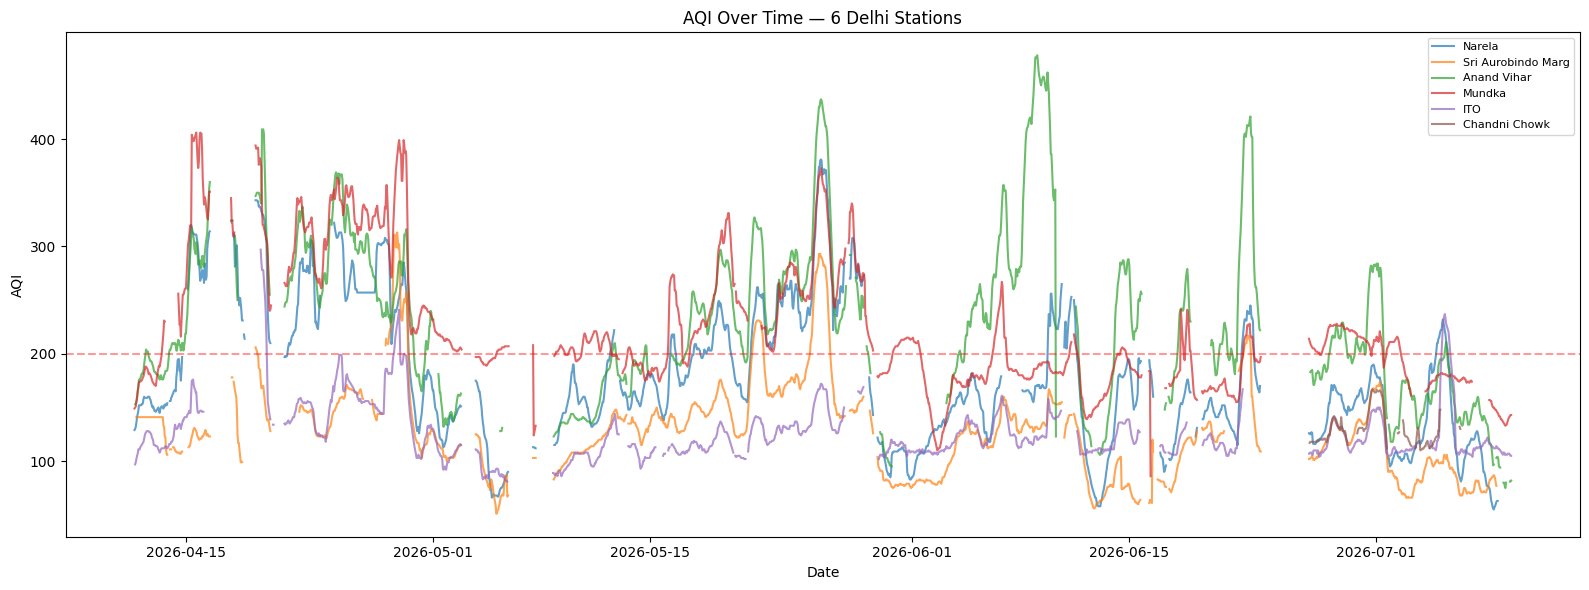

In [18]:
stations_to_plot = [
    'Narela, Delhi - DPCC',
    'Sri Aurobindo Marg, Delhi - DPCC',
    'Anand Vihar, New Delhi - DPCC',
    'Mundka, Delhi - DPCC',
    'ITO, New Delhi - CPCB',
    'Chandni Chowk, Delhi - IITM',
]

fig, ax = plt.subplots(figsize=(16, 6))

for station in stations_to_plot:
    sub = df[df['station_name'] == station].sort_values('timestamp_hour')
    ax.plot(sub['timestamp_hour'], sub['current_aqi'],
            label=station.split(',')[0], alpha=0.7)

ax.set_title('AQI Over Time — 6 Delhi Stations')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend(fontsize=8)
ax.axhline(200, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../eda/plot1_aqi_timeseries.png', dpi=150)
plt.show()

## Findings from the graph: 
- Overall, the AQI stations are moving together city-wide. Although, the magnitude differs in nature.
- Chandni Chowk has only 7.7% valid AQI. Decision: flag as low reliability station during cleaning phase rather than dropping — preserves geographic coverage while reducing its weight in proximity models
- Anand Vihar shows the highest pollution spike among all the stations, which maes complete sense considering its a major bus terminal and highway intersection in East Delhi. The spikes are real. 

## Plot 2 — Missing Value Heatmap

We pivot the data from long format to wide format (rows = timestamps, columns = stations)
so missingno can visualise gap patterns across all 38 stations simultaneously.

- Dark = data present
- White = data missing

We are looking for: random dropout (interpolation), station outages (proxy fill), 
or systematic patterns (maintenance windows).

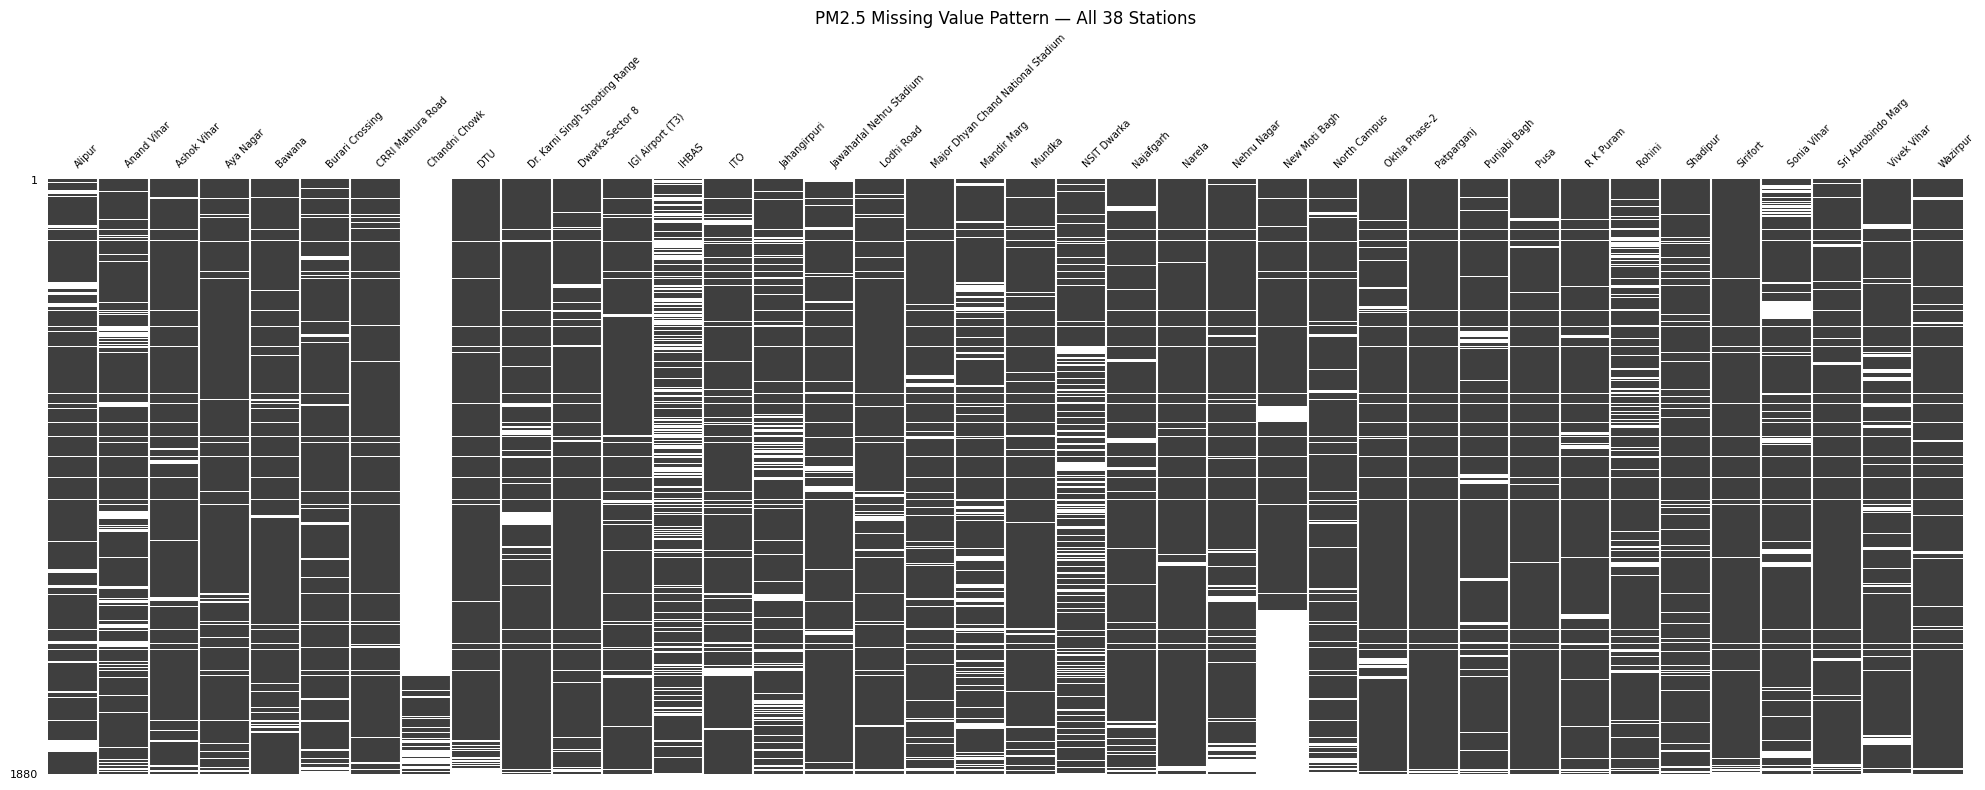

In [19]:
import missingno as msno

pivot = df.pivot_table(
    index='timestamp_hour',
    columns='station_name',
    values='pm25'
)

# Shorten column names for readability
pivot.columns = [c.split(',')[0] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(20, 8))
msno.matrix(pivot, ax=ax, sparkline=False, fontsize=7)
ax.set_title('PM2.5 Missing Value Pattern — All 38 Stations')
plt.tight_layout()
plt.savefig('../eda/plot2_missing_heatmap.png', dpi=150)
plt.show()


 ## Missingness interpretation

The missingness heatmap shows that pollutant availability varies across stations and time. However, this visualization alone cannot determine whether the gaps are random, station-specific, or caused by a synchronized provider outage.

The later programmatic cleaning audit identified 70 timestamps where at least four pollutants were missing at 90% or more of stations. These timestamps were treated as synchronized data-availability outages and removed rather than imputed.

## Plot 3 — Wind Rose

Polar plot showing wind direction frequency weighted by speed.
We are looking for dominant wind directions in our April-July dataset
to validate that our emission source locations will align with 
actual wind patterns — critical for upwind score calculation on Day 7.

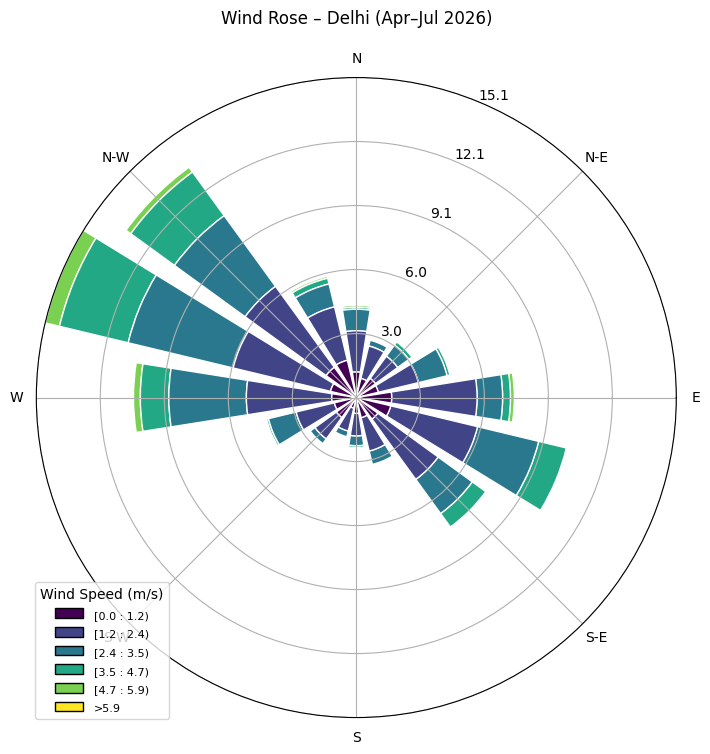

In [20]:
from windrose import WindroseAxes

wind_df = df[
    df["station_name"] == "ITO, New Delhi - CPCB"
].copy()

wind_df = wind_df.dropna(
    subset=["wind_speed_10m", "wind_direction_10m"]
)

# Original wind speed is km/h; convert it for the plot.
wind_df["wind_speed_10m_ms"] = (
    wind_df["wind_speed_10m"] / 3.6
)

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(
    wind_df["wind_direction_10m"],
    wind_df["wind_speed_10m_ms"],
    normed=True,
    opening=0.8,
    edgecolor="white"
)

ax.set_title("Wind Rose – Delhi (Apr–Jul 2026)", pad=20)
ax.set_legend(title="Wind Speed (m/s)")

plt.savefig("../eda/plot3_wind_rose.png", dpi=150)
plt.show()

## Plot 3 Findings — Wind Rose

- Dominant wind direction: West and Northwest (monsoon onset pattern, Apr–Jul)
- High speed winds (8.5–17 m/s) predominantly from NW direction
- implication for Day 7: emission sources database should prioritize 
  sources to the West and Northwest of sensors — these directions will 
  generate the most meaningful upwind scores in this dataset

## Plot 4 — Wind Direction vs PM2.5

We bin wind direction into 8 compass sectors and compute mean PM2.5 per sector.
This validates our upwind score concept — if wind from specific directions 
consistently brings higher PM2.5, it confirms pollution sources exist in those directions.

If no pattern exists, our attribution approach has a fundamental

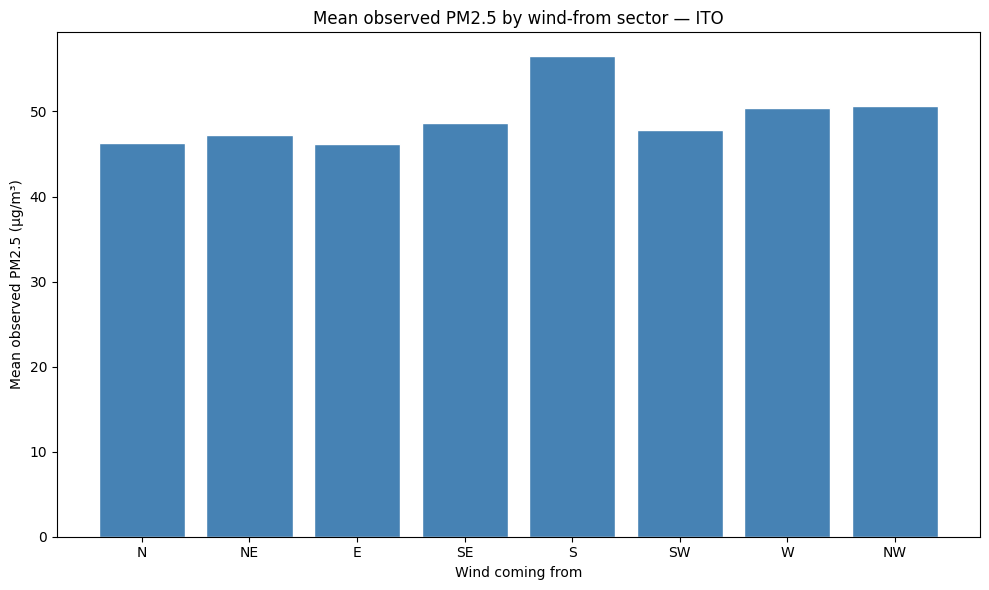

In [23]:
ito = df[
    df["station_name"] == "ITO, New Delhi - CPCB"
].copy()

ito = ito.dropna(
    subset=["wind_direction_10m", "pm25"]
)

direction_labels = np.array(
    ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
)

# Add 22.5° so each 45° sector is centred on its compass direction.
sector_index = (
    ((ito["wind_direction_10m"] + 22.5) // 45) % 8
).astype(int)

ito["wind_sector"] = pd.Categorical(
    direction_labels[sector_index],
    categories=direction_labels.tolist(),
    ordered=True
)

sector_pm25 = (
    ito.groupby(
        "wind_sector",
        observed=True
    )["pm25"]
    .mean()
    .reindex(direction_labels)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    direction_labels,
    sector_pm25,
    color="steelblue",
    edgecolor="white"
)

ax.set_title("Mean observed PM2.5 by wind-from sector — ITO")
ax.set_xlabel("Wind coming from")
ax.set_ylabel("Mean observed PM2.5 (µg/m³)")

plt.tight_layout()
plt.savefig("../eda/plot4_wind_vs_pm25.png", dpi=150)
plt.show()

## Plot 4 Findings — Wind Direction vs PM2.5

- Mean PM2.5 varies moderately across the eight wind-from sectors, approximately from 46 to 56 µg/m³.
- The south sector has the highest mean PM2.5 in this sample.
- This is a descriptive association, not evidence that a southern emission source caused the higher concentration.
- Directional averages may also be affected by time of day, weather, seasonal conditions and unequal observation counts.
- Source attribution would require source locations, activity information, wind alignment and possible pollutant-transport lag.

# EDA Summary — Key Findings and Decisions

## What We Found

- The pre-cleaning dataset contains 82,004 station-hour rows from 38 stations across approximately 89 days.
- Pollutant availability varies substantially across stations and time.
- Missingness cannot be assumed to be random based only on the heatmaps.
- The later programmatic audit identified 70 synchronized multi-pollutant outage timestamps.
- SO2 has the lowest overall availability and is structurally unavailable at several stations.
- Chandni Chowk has low valid-AQI coverage, but this does not by itself justify removing or automatically down-weighting the station.
- Some stations contain long or structural pollutant gaps that should not automatically be filled from another station.
- Wind patterns provide descriptive meteorological context but do not independently identify emission sources.

## Decisions for Cleaning

1. Preserve original pollutant availability using `has_<pollutant>` flags.
2. Detect and remove synchronized provider-outage timestamps before any interpolation or proxy processing.
3. Allow only limited, explicitly flagged interpolation for short internal gaps.
4. Keep proxy estimates traceable and separate from original observations.
5. Do not proxy-fill a pollutant at a station that has never measured that pollutant.
6. Calculate AQI from original observations before interpolation or proxy processing.
7. Validate data types, units, duplicates, missingness and chronological ordering programmatically.

## Source-Context Decision

- Emission-source locations must come from an external, documented source inventory.
- Wind direction may later help rank nearby source context, but it is not proof of source attribution.
- No emission sources should be placed or prioritized solely because of the EDA wind plots.

